# Notebook 02 - Synthetic Data Generation Pipeline

**Authors:** Ivo Rambaldi & Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

---

## Overview

This notebook implements **Goal 2** of the project: given the preprocessed training dataset produced by Goal 1, generate multiple synthetic datasets using four distinct synthesis strategies. The methods implemented are shown in the table below.

| Method | Type | Key property |
|--------|------|--------------|
| **Gaussian Copula** | Statistical | Lightweight baseline; explicit correlation structure |
| **CTGAN** | Deep generative (GAN) | Mode-specific normalisation; conditional generation |
| **TVAE** | Deep generative (VAE) | Stable training; good joint structure |
| **SMOTE** | Oversampling | Minority-class focused; interpolation-based; class-balancing |

The synthetic datasets produced here are the direct input for **Notebook 04**, which runs the TSTR (Train on Synthetic, Test on Real) evaluation matrix.

---

### About the target variable

The raw Aequitas dataset contains **no pre-built binary target column**. The dataset provides continuous performance scores (`score_MAT`, `score_LEN`, `score_ING`) and their ordinal level variants (1-4).

The binary classification target is constructed by **Notebook 01** by applying a percentile threshold to the score, following the methodology of Marrero et al. (ECAI 2024), which discretises performance into quartiles to define excellence (upper tail, $\geq 75$-th percentile) and underperformance (lower tail, $\leq 25$-th percentile) detection tasks.

Our project focuses on the **excellence detection task**: a student is labelled positive (`target_high_perf = 1`) if their `score_MAT` is $\geq$ the $75$-th percentile of the training split. The threshold is computed on the training set only to prevent data leakage.

The threshold and target column name are fully configurable via `config.yaml`:
```yaml
target:
  score_column: score_MAT
  percentile:   75
  column_name:  target_high_perf
```

---

### Notebook output

This noteboook produces four CSV files written to `results/synthetic/<method>/synthetic_<method>.csv`:

```
results/synthetic/
 |- copula/synthetic_copula.csv
 |- ctgan/synthetic_ctgan.csv
 |- tvae/synthetic_tvae.csv
 |- smote/synthetic_smote.csv
```

## 1. Environment Setup

### 1.1 Path and import setup

In [ ]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd


# Ensure the project root is on sys.path so 'src' imports resolve correctly
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



from src.utils.config import load_config
from src.utils.logging import get_logger

logger = get_logger('notebook_02')

# Suppress SDV FutureWarning about metadata API
warnings.filterwarnings('ignore', category=FutureWarning, module='sdv')
warnings.filterwarnings('ignore', category=UserWarning,   module='sdv')

logger.info("Environment ready. Project root: %s", PROJECT_ROOT)

ModuleNotFoundError: No module named 'src'

### 1.2 Load configuration

In [ ]:
# Load config.yaml
cfg = load_config(PROJECT_ROOT / 'config' / 'config.yaml')

# Print key config values for reproducibility
print('=== Configuration summary ===')
print(f"  seed            : {cfg['seed']}")
print(f"  train_data      : {cfg['paths']['train_data']}")
print(f"  synthetic_dir   : {cfg['paths']['synthetic_dir']}")
print(f"  target column   : {cfg['dataset']['target_column']}")
print(f"  n_synthetic     : {cfg['generation']['n_synthetic_samples']}  (None = match train size)")
print(f"  methods         : {[k for k, v in cfg['generation']['methods'].items()]}")


=== Configuration summary ===
  seed            : 42
  train_data      : C:\Users\tomma\Desktop\petrellirambaldi2526\students-dataset\mock_final.csv
  synthetic_dir   : C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic
  target column   : target_high_perf
  n_synthetic     : None  (None = match train size)
  enabled methods : ['ctgan', 'tvae', 'gaussian_copula', 'smote']


## 2. Loading the Training Dataset

We load the preprocessed training dataset produced by **Notebook 01** (Goal 1).

### 2.1 MNAR decision

We deliberately **do not impute** missing values in the family questionnaire block (`f_mother_education_level`, `f_father_education_level`, `f_ESCS`, etc.) because the dataset paper (Giovanelli et al., 2026) establishes that these missingness patterns are **MNAR** (Missing Not At Random): they reflect social exclusion, meaning that families from disadvantaged socioeconomic backgrounds are more likely to decline to answer sensitive questions out of fear or stigma.

Imputing MNAR values would suppress the very signal that indicates which students are most at risk. This is an *ethical* choice, not merely a technical one. We pass missing values directly to the synthesizers and record how each method handles them in Section 5.

### 2.2 Why exclude performance score columns from synthesis

The columns `score_MAT`, `level_MAT`, `score_LEN`, `level_LEN`, `score_ING`, `level_ING` are listed under `dataset.performance_columns` in `config.yaml` and are excluded from the features passed to the synthesizers. The reason is subtle but important:

The binary target `target_high_perf` was derived directly from `score_MAT` (score $\geq 75$-th percentile). If we included `score_MAT` in synthesis, any generative model would trivially learn to reconstruct the target from the score, inflating utility metrics. More importantly, the performance scores are the **outcome variables** in the longitudinal design of paper17,
not inputs. What we want to synthesise is the student's circumstance and contextual profile; the target should be predicted from that profile by a downstream classifier.

In [ ]:
from src.data.loader import load_dataset, describe_dataset

# drop_id_columns=True removes questionnaire/school IDs (no distributional signal).
# Performance score columns are handled separately below.
train_df_full = load_dataset(cfg['paths']['train_data'], cfg, drop_id_columns=True)

# Drop performance score columns before synthesis
perf_cols = [c for c in cfg['dataset'].get('performance_columns', []) if c in train_df_full.columns]
train_df = train_df_full.drop(columns=perf_cols)

print(f'Full loaded shape : {train_df_full.shape}')
print(f'Dropped perf cols : {perf_cols}')
print(f'For synthesis     : {train_df.shape}')
print()
describe_dataset(train_df, cfg)

2026-06-07 16:55:34 | INFO     | src.data.loader | Loading dataset from C:\Users\tomma\Desktop\petrellirambaldi2526\students-dataset\mock_final.csv
2026-06-07 16:55:34 | INFO     | src.data.loader | Loaded  500 rows x 30 columns
2026-06-07 16:55:34 | INFO     | src.data.loader | Dropped 5 id columns: ['id_questionnaire', 'id_student_original', 'id_year', 'id_grade', 'id_school']
Full loaded shape : (500, 25)
Dropped perf cols : ['score_MAT', 'level_MAT', 'score_LEN', 'level_LEN', 'score_ING', 'level_ING']
For synthesis     : (500, 19)

  Dataset summary
  Shape : 500 rows x 19 columns
  Target: 'target_high_perf'  ->  {0: 375, 1: 125}

  Missing values (7 columns with > 0% missing):
    f_father_education_level                                23.0%
    f_frequency_of_see_adult_read                           20.8%
    f_extent_of_books_at_home                               20.6%
    f_mother_education_level                                20.2%
    f_father_occupation                     

In [ ]:
# Target distribution should be ~25% positive for a 75th-percentile threshold
target = cfg['dataset']['target_column']
counts = train_df[target].value_counts()

print(f'Target distribution ({target}):')
print(counts.to_string())
print(f'Positive rate: {train_df[target].mean():.1%}  (expected ~25% for 75th-pct threshold)')

Target distribution (target_high_perf):
target_high_perf
0    375
1    125
Positive rate: 25.0%  (expected ~25% for 75th-pct threshold)


## 3. Methodological Framing: Why These Four Methods?

Our choice of synthesis strategies covers three distinct paradigms. This is deliberate: by comparing methods across paradigms, we can attribute changes in fairness and utility to the *type* of generation rather than to any single implementation.

### 3.1 Gaussian Copula (statistical baseline)

A copula models marginal distributions and their correlations separately (Sklar's theorem). The Gaussian Copula assumes that correlations between variables, once normalised to uniform marginals, follow a multivariate Gaussian distribution.

**Why include it?** It is fully interpretable (the covariance matrix is directly inspectable), fast, and provides a ceiling estimate for how much of the utility/fairness loss is attributable to simple distributional distortion vs. deep-model artefacts.

**Known limitation:** The Gaussian correlation assumption may fail for heavily skewed or multi-modal features.

### 3.2 CTGAN (Conditional GAN for tabular data)

CTGAN (Xu et al., 2019) addresses two core challenges in tabular synthesis:
1. **Multi-modal continuous distributions**: handled by mode-specific normalisation (fitting a Gaussian mixture and normalising each mode separately).
2. **Imbalanced categorical columns**: handled by a conditional vector that oversamples under-represented categories during training.

**Why include it?** It is the de-facto standard deep generative model for tabular data and the most-cited baseline in the synthetic data literature.

**Known limitation:** GAN training instability; mode collapse possible on
sparse high-cardinality features.

### 3.3 TVAE (Variational Autoencoder for tabular data)

TVAE (Xu et al., 2019) maps rows to a continuous latent space via an encoder and reconstructs them via a decoder. Sampling is done by drawing from the learned latent distribution (typically a Gaussian prior).

**Why include it?** Unlike CTGAN, TVAE training is stable (no adversarial dynamics). Including both lets us disentangle training stability from data quality effects.

**Known limitation:** TVAE can produce blurrier marginals than CTGAN, particularly for categorical columns.

### 3.4 SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE is *not* a generative model. It is an oversampling technique that adds synthetic minority-class rows by interpolating between k-nearest neighbours in feature space.

**Why include it?** SMOTE is widely used in practice as a data augmentation technique. By including it, we can empirically test whether its class-balancing property helps or hurts fairness relative to methods that model the full joint distribution.

**Ethical note:** SMOTE's interpolation is defined over the feature space of the *minority class only*. For this dataset the minority class may correspond to a specific demographic group (e.g., students from low-SES families who score below the threshold). Interpolating *within* this group may introduce artefacts that distort the representation of those subgroups in ways that impact fairness metrics. We document this in Section 5.

---

### 3.5 Key design decision: equal sample size

All methods are configured to produce the **same number of synthetic rows as the training set** (controlled by `generation.n_synthetic_samples: null` in `config.yaml`). This ensures that downstream utility/fairness comparisons are not confounded by different dataset sizes.

**** TODO: are we sure we want to use SMOTE like this? ****
The one exception is SMOTE: it *adds* rows to achieve class balance, so its output will be larger than the other methods if the training data is imbalanced. We document the resulting size and class distribution explicitly in the output section.

## 4. Hyperparameters and Configuration

All hyperparameters are defined in `config/config.yaml`. We read and display them here to ensure the notebook output is a self-contained record of the experiment configuration.

In [ ]:
print('=== Generation hyperparameters ===')
gen_cfg = cfg['generation']
print(f"  n_synthetic_samples : {gen_cfg['n_synthetic_samples']}")
print()
for method, params in gen_cfg['methods'].items():
    print(f'  [{method}]')
    for k, v in params.items():
        print(f'    {k}: {v}')
    print()

=== Generation hyperparameters ===
  n_synthetic_samples : None

  [ctgan]
    enabled: True
    epochs: 300
    batch_size: 500

  [tvae]
    enabled: True
    epochs: 300
    batch_size: 500

  [gaussian_copula]
    enabled: True

  [smote]
    enabled: True
    k_neighbors: 5



### 4.1 Hyperparameter rationale

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `epochs` (CTGAN / TVAE) | 300 | Standard default from the SDV library; sufficient for datasets of this size (~few thousand rows). We prioritise reproducibility over tuning. |
| `batch_size` | 500 | Balances GPU/CPU memory usage and gradient variance. |
| `k_neighbors` (SMOTE) | 5 | Default from the imbalanced-learn library; well-established for mixed-type data. |
| `percentile` (target) | 75 | Excellence detection task following paper17. Produces ~25% positive rate. |
| `seed` | 42 | Fixed for reproducibility across all runs. |

Note: we intentionally do **not** tune hyperparameters per method. Our goal is to compare the *inherent* fairness/utility properties of each approach, not to optimise any single method. Tuning would introduce a confound.

## 5. Running the Generation Pipeline

**** TODO: write here the pipeline instead of calling the function ****
The `run_generation_pipeline` function in `src/generation/pipeline.py` orchestrates all four generators. It:
1. Builds SDV `SingleTableMetadata` from the DataFrame (column types, no primary key).
2. For each enabled method: fits the synthesizer, samples the configured number of rows, and writes the result to `data/synthetic/<method>/synthetic_<method>.csv`.
3. Returns a dict `{method_name: synthetic_DataFrame}`.

In [ ]:
from src.generation.metadata import build_metadata


methods_cfg = cfg["generation"]["methods"]
synthetic_datasets: dict[str, pd.DataFrame] = {}

# Build SDV metadata once shared by all SDV-based generators.
logger.info("Building SDV metadata...")
metadata = build_metadata(train_df, cfg)

2026-06-07 16:55:57 | INFO     | notebook_02 | Building SDV metadata...
2026-06-07 16:55:57 | INFO     | src.generation.metadata | Metadata built: 12 categorical, 7 numerical columns


### 5.1 CTGAN

In [ ]:
from src.generation.ctgan_gen import generate_ctgan
from src.utils.config import get_synthetic_output_path

logger.info("Running CTGAN...")
output_path = get_synthetic_output_path(cfg, "ctgan")
synthetic_datasets["ctgan"] = generate_ctgan(
    train_df, metadata, cfg, output_path
)

2026-06-07 16:55:57 | INFO     | notebook_02 | ==================================================
2026-06-07 16:55:57 | INFO     | notebook_02 | Running CTGAN...
2026-06-07 16:55:57 | INFO     | src.generation.ctgan_gen | CTGAN: fitting on 500 rows (epochs=300, batch_size=500, seed=42)...


Gen. (-00.31) | Discrim. (+00.13): 100%|██████████| 300/300 [01:12<00:00,  4.14it/s]

2026-06-07 16:58:40 | INFO     | src.generation.ctgan_gen | CTGAN: sampling 500 synthetic rows...


2026-06-07 16:58:41 | INFO     | src.generation.ctgan_gen | CTGAN: synthetic dataset saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\ctgan\synthetic_ctgan.csv  (500 rows)


### 5.2 TVAE

In [ ]:
from src.generation.tvae_gen import generate_tvae

logger.info("Running TVAE...")
output_path = get_synthetic_output_path(cfg, "tvae")
synthetic_datasets["tvae"] = generate_tvae(
    train_df, metadata, cfg, output_path
)

2026-06-07 16:58:42 | INFO     | notebook_02 | ==================================================
2026-06-07 16:58:42 | INFO     | notebook_02 | Running TVAE...
2026-06-07 16:58:42 | INFO     | src.generation.tvae_gen | TVAE: fitting on 500 rows (epochs=300, batch_size=500, seed=42)...


Loss: +34.06: 100%|██████████| 300/300 [00:20<00:00, 14.36it/s]

2026-06-07 16:59:10 | INFO     | src.generation.tvae_gen | TVAE: sampling 500 synthetic rows...


2026-06-07 16:59:10 | INFO     | src.generation.tvae_gen | TVAE: synthetic dataset saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\tvae\synthetic_tvae.csv  (500 rows)


### 5.3 Gaussian Copula

In [ ]:
from src.generation.copula_gen import generate_gaussian_copula

logger.info("Running Gaussian Copula...")
output_path = get_synthetic_output_path(cfg, "gaussian_copula")
synthetic_datasets["gaussian_copula"] = generate_gaussian_copula(
    train_df, metadata, cfg, output_path
)

2026-06-07 16:59:10 | INFO     | notebook_02 | ==================================================
2026-06-07 16:59:10 | INFO     | notebook_02 | Running Gaussian Copula...
2026-06-07 16:59:10 | INFO     | src.generation.copula_gen | GaussianCopula: fitting on 500 rows...
2026-06-07 16:59:13 | INFO     | src.generation.copula_gen | GaussianCopula: sampling 500 synthetic rows...
2026-06-07 16:59:13 | INFO     | src.generation.copula_gen | GaussianCopula: synthetic dataset saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\copula\synthetic_copula.csv  (500 rows)


### 5.4 SMOTE

In [ ]:
from src.generation.smote_gen import generate_smote


logger.info("=" * 50)
logger.info("Running SMOTE...")
output_path = get_synthetic_output_path(cfg, "smote")
synthetic_datasets["smote"] = generate_smote(
    train_df, cfg, output_path
)

2026-06-07 16:59:14 | INFO     | notebook_02 | ==================================================
2026-06-07 16:59:14 | INFO     | notebook_02 | Running SMOTE...
2026-06-07 16:59:14 | INFO     | src.generation.smote_gen | SMOTE: fitting on 500 rows (k_neighbors=5, seed=42)...
2026-06-07 16:59:14 | INFO     | src.generation.smote_gen | Categorical column indices: [0, 1, 7, 8, 9]
2026-06-07 16:59:14 | INFO     | src.generation.smote_gen | SMOTE: filled NaNs in 7 columns for kNN computation.
2026-06-07 16:59:14 | INFO     | src.generation.smote_gen | SMOTE: resampled to 750 rows  (original: 500)
2026-06-07 16:59:14 | INFO     | src.generation.smote_gen | Class distribution after resampling: {0: 375, 1: 375}
2026-06-07 16:59:14 | INFO     | src.generation.smote_gen | SMOTE: synthetic dataset saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote\synthetic_smote.csv  (750 rows)


### 5.5 Output summary

In [ ]:
print('=== Generation complete ===')
for method, df in synthetic_datasets.items():
    pos_rate = df[target].mean() if target in df.columns else float('nan')
    print(
        f'  {method:<20}  {len(df):>6,} rows x {df.shape[1]} cols  '
        f'positive_rate={pos_rate:.1%}'
    )

=== Generation complete ===
  ctgan                    500 rows x 19 cols  positive_rate=26.8%
  tvae                     500 rows x 19 cols  positive_rate=0.0%
  gaussian_copula          500 rows x 19 cols  positive_rate=22.4%
  smote                    750 rows x 19 cols  positive_rate=50.0%


## 6. Fidelity Evaluation

Before passing the synthetic datasets to Goal 3 (utility and fairness measurement), we perform a **fidelity sanity check**: does the synthetic data look statistically similar to the real training data?

We compute three complementary fidelity metrics:

| Metric | Scope | What it measures |
|--------|-------|------------------|
| **MMD** (Maximum Mean Discrepancy) | Numerical columns | Overall distributional distance between real and synthetic (kernel-based, 0 = identical) |
| **Spearman correlation MAE** | Numerical columns | Mean absolute difference in rank correlations between real and synthetic |
| **KL divergence** | Categorical columns | Per-column divergence of category frequencies |

These are *fidelity* metrics. They are distinct from *utility* metrics (i.e. does training on synthetic -> good performance on real?) and *fairness* metrics (does synthetic preserve equity across protected groups?), which are computed in Goal 3.

These metrics are used *within* Goal 2 to sanity-check each synthesizer before passing the data to Goal 3 (utility/fairness evaluation). A synthesizer that fails basic fidelity checks is not worth evaluating further.

**Interpretation guide:**
- A low MMD does not guarantee good utility: the model could hallucinate
realistic-looking marginals while destroying joint structure.
- A high KL divergence on a protected attribute column (e.g., `s_gender`)
is a direct early warning of potential fairness distortion.

In [ ]:
from src.generation.fidelity import compute_fidelity_report, pprint_fidelity_report

fidelity_reports = {}
for method, syn_df in synthetic_datasets.items():
    report = compute_fidelity_report(train_df, syn_df, cfg, method_name=method)
    fidelity_reports[method] = report
    pprint_fidelity_report(report)

2026-06-07 17:40:12 | INFO     | src.generation.fidelity | Computing fidelity report for method=ctgan
2026-06-07 17:40:12 | INFO     | src.generation.fidelity |   MMD=0.2545  corr_MAE=0.0499  mean_KL=0.0159

  Fidelity Report — method: ctgan
  Real rows    : 500
  Synthetic rows: 500
  MMD (RBF)    : 0.254516  (lower is better)
  Corr MAE     : 0.0499  (lower is better)
  Mean KL div  : 0.0159  (lower is better)

  Per-column KL divergences (categorical):
    f_frequency_of_see_adult_read                            0.0554
    s_gender                                                 0.0135
    p_island                                                 0.0077
    s_birth_country                                          0.0022
    p_public_or_private                                      0.0005

  Column statistics (numerical columns — top 8):
    f_mother_education_level                       mean: real=4.020 / syn=4.015  std: real=2.030 / syn=2.046
    f_father_education_level             

### 6.1 Protected attribute fidelity

We specifically inspect whether the synthesizers preserve the distributions of protected attributes, namely the circumstances $C_1$-$C_{12}$. Distortions here directly imply that fairness metrics computed downstream will differ from those on real data.

In [ ]:
# Per protected-attribute KL divergence across all methods
protected_attrs = cfg['dataset']['protected_attributes']
cat_cols = set(cfg['dataset'].get('categorical_columns', []))

# Collect KL divergences for categorical protected attributes
protected_kl_table = {}
for attr in protected_attrs:
    if attr not in train_df.columns:
        continue
    if train_df[attr].dtype != object and attr not in cat_cols:
        continue  # numerical protected attributes: skip KL, covered by MMD
    protected_kl_table[attr] = {}
    for method, report in fidelity_reports.items():
        kl = report['kl_divergences'].get(attr, float('nan'))
        protected_kl_table[attr][method] = kl

if protected_kl_table:
    kl_df = pd.DataFrame(protected_kl_table).T
    print('KL divergence for categorical protected attributes (lower is better):')
    print(kl_df.to_string(float_format='{:.4f}'.format))
else:
    print('No categorical protected attributes with KL data available.')

KL divergence for categorical protected attributes (lower is better):
                               ctgan   tvae  gaussian_copula  smote
s_gender                      0.0135 0.0950           0.0014 0.0016
s_birth_country               0.0022 4.9221           0.0003 0.0134
f_frequency_of_see_adult_read 0.0554 0.2892           0.0059 0.0863
p_public_or_private           0.0005 6.0210           0.0014 0.0068
p_island                      0.0077 0.2636           0.0002 0.0117


## 7. Visualisations

Visual inspection of marginal distributions is a key sanity check. We plot the distribution of the target variable and selected protected attributes across all methods.

Figures are automatically saved to `results/figures/`.

2026-06-07 17:46:44 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\class_balance.png


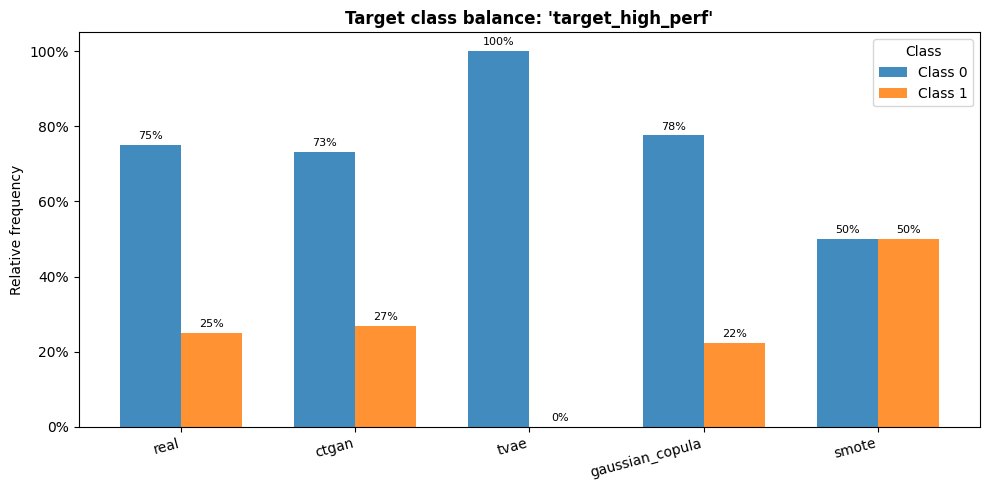

In [ ]:
from src.utils.plotting import (
    plot_class_balance,
    plot_fidelity_summary,
    plot_marginal_distributions
)

# Class balance across methods
fig_balance = plot_class_balance(train_df, synthetic_datasets, cfg, save=True)
plt.show(); plt.close()

C:\Users\tomma\Desktop\petrellirambaldi2526\src\utils\plotting.py:262: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha="right")
C:\Users\tomma\Desktop\petrellirambaldi2526\src\utils\plotting.py:262: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha="right")


2026-06-07 17:46:48 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\fidelity_summary.png


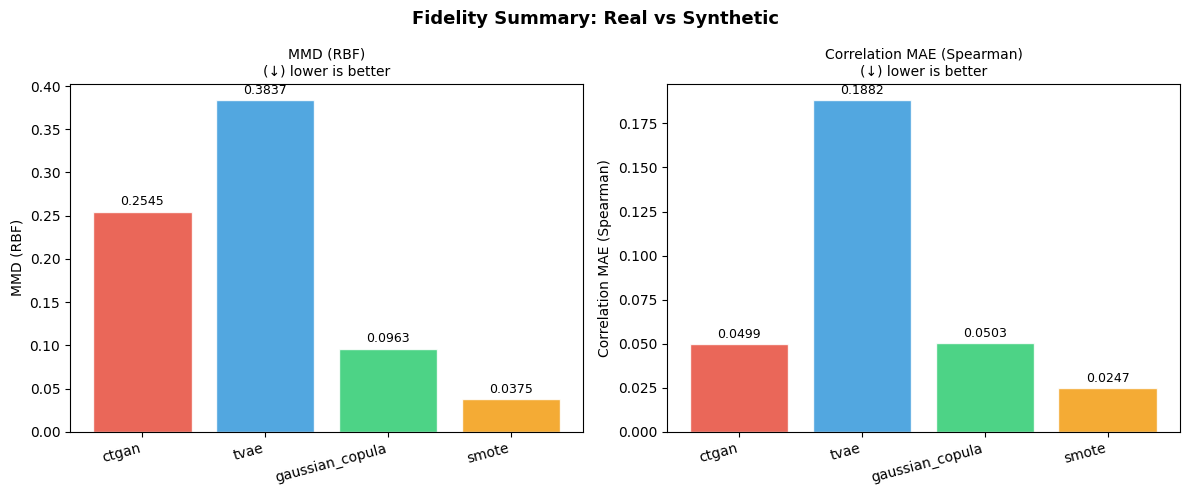

In [ ]:
# Fidelity summary (MMD + corr MAE)
fig_fidelity = plot_fidelity_summary(list(fidelity_reports.values()), cfg, save=True)
plt.show(); plt.close()

2026-06-07 17:48:22 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\marginal_target_high_perf.png


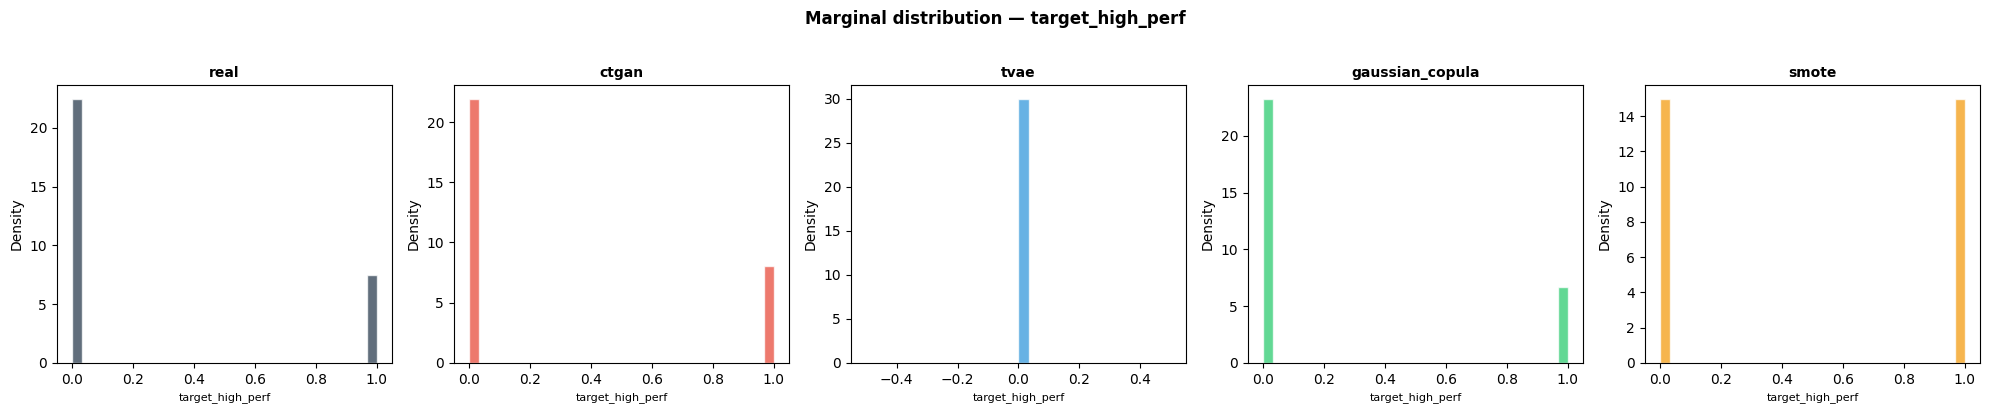

2026-06-07 17:48:24 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\marginal_s_gender.png


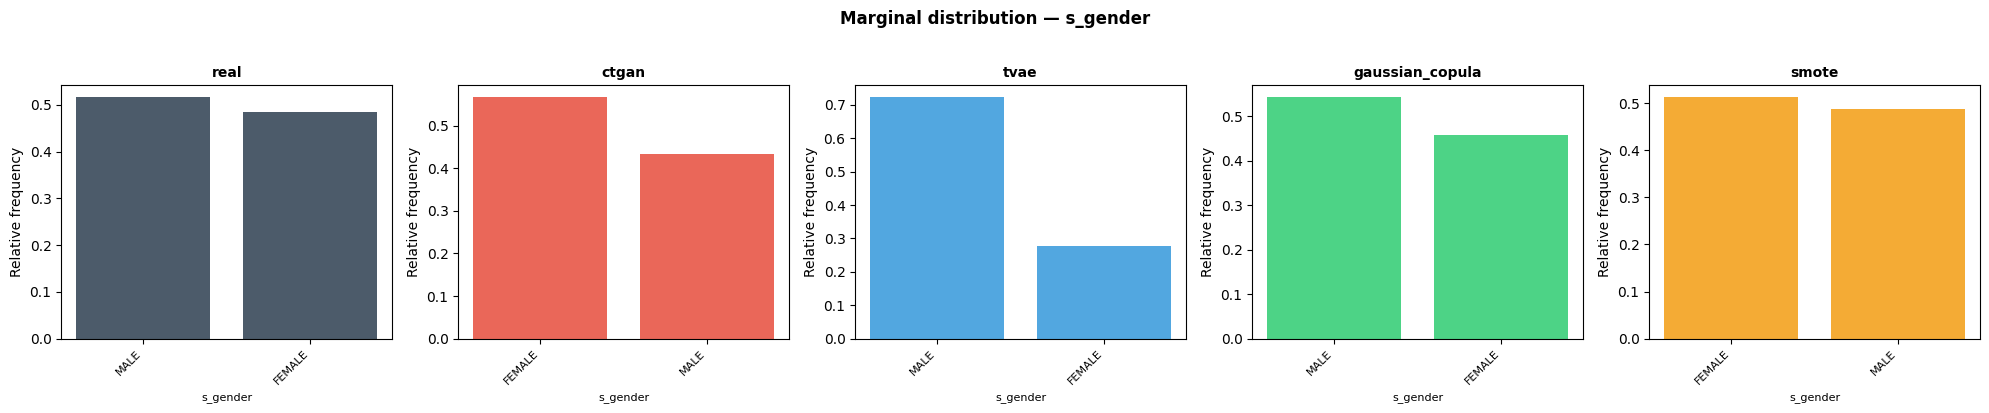

2026-06-07 17:48:26 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\marginal_p_public_or_private.png


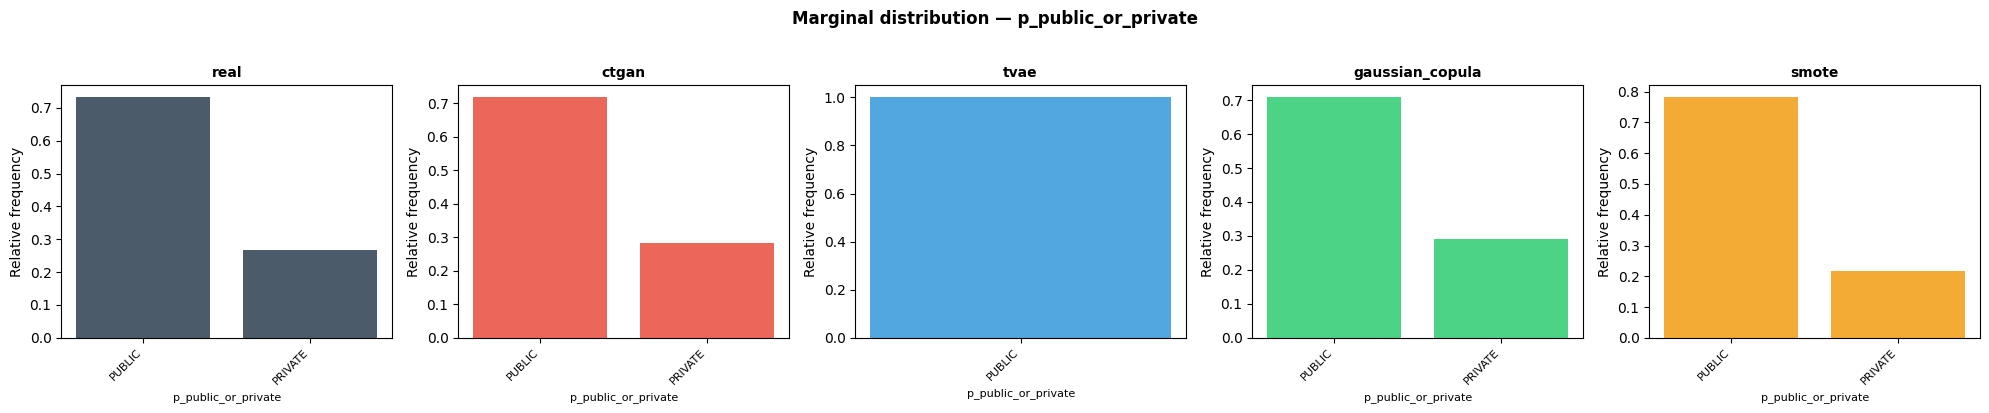

In [ ]:
# Marginal distributions for the target column and two key protected attributes
cols_to_plot = [
    cfg['dataset']['target_column'],
    's_gender',
    'p_public_or_private',
]

for col in cols_to_plot:
    if col in train_df.columns:
        fig = plot_marginal_distributions(train_df, synthetic_datasets, col, cfg, save=True)
        plt.show(); plt.close()
    else:
        print(f'Column {col!r} not found in train_df... skipping.')

## 8. SMOTE: Special Considerations

SMOTE requires separate analysis because its semantics differ fundamentally from the other three methods.

### 8.1 Class balance change

SMOTE oversamples the **minority class** until class balance is achieved (1:1 ratio by default). This means:
- The synthetic dataset produced by SMOTE is typically *larger* than the training set.
- The target distribution in the synthetic set is artificially balanced, which is *not* representative of the real world.

This matters for our TSTR evaluation: a classifier trained on SMOTE-synthetic data may be calibrated for a 50/50 world, which could produce different fairness metric outcomes than a classifier trained on real-proportion data.

### 8.2 Representation of minority subgroups within the minority class

The minority class (top 25% performers) is not demographically uniform: it is disproportionately composed of students from high-SES backgrounds (high `f_ESCS`, tertiary-educated parents, more books at home). SMOTE interpolates *within* this already-privileged subpopulation, potentially creating synthetic students who cluster around the 'average high-SES high performer' and underrepresent the minority within the minority: high-performing students from disadvantaged backgrounds.

The analysis below quantifies this effect.

In [ ]:
if 'smote' in synthetic_datasets:
    smote_df = synthetic_datasets['smote']
    target = cfg['dataset']['target_column']

    print('=== SMOTE class distribution ===')
    print(f'  Real    : {train_df[target].value_counts().to_dict()}')
    print(f'  SMOTE   : {smote_df[target].value_counts().to_dict()}')
    print(f'  Real size  : {len(train_df):,} rows')
    print(f'  SMOTE size : {len(smote_df):,} rows (+{len(smote_df)-len(train_df):,} synthetic)')

    # Check if protected attribute distributions differ between real minority
    # class and SMOTE synthetic minority class
    print('\n=== Protected attribute distributions - minority class only ===')
    print('  (Positive = high performer, i.e. score_MAT >= 75th percentile)')
    for attr in ['s_gender', 'p_public_or_private']:
        if attr not in train_df.columns:
            continue
        real_min  = train_df.loc[train_df[target]==0, attr].value_counts(normalize=True)
        smote_min = smote_df.loc[smote_df[target]==0, attr].value_counts(normalize=True)
        print(f'  {attr}:')
        print(f'    Real  minority: {real_min.to_dict()}')
        print(f'    SMOTE minority: {smote_min.to_dict()}')
        print()
else:
    print('SMOTE was not enabled.')

=== SMOTE class distribution ===
  Real    : {0: 375, 1: 125}
  SMOTE   : {0: 375, 1: 375}
  Real size  : 500 rows
  SMOTE size : 750 rows (+250 synthetic)

=== Protected attribute distributions - minority class only ===
  (Positive = high performer, i.e. score_MAT >= 75th percentile)
  s_gender:
    Real  minority: {'MALE': 0.528, 'FEMALE': 0.472}
    SMOTE minority: {'MALE': 0.528, 'FEMALE': 0.472}

  p_public_or_private:
    Real  minority: {'PUBLIC': 0.7226666666666667, 'PRIVATE': 0.2773333333333333}
    SMOTE minority: {'PUBLIC': 0.7226666666666667, 'PRIVATE': 0.2773333333333333}



## 9. Final wrap-up

****TODO: summarise MMD, KL divergence and correlation MAE results here.****